## Modelo Marítimo

Import CSV de Series

In [1]:
import pandas as pd

def cargar_serie(path):
    s = pd.read_csv(path, index_col=0, parse_dates=True)['Viajero']
    s = s.asfreq('MS')  # el CSV no guarda la frecuencia, hay que reasignarla
    return s

train_serie = cargar_serie('../../Datos/train_via_ingreso_maritima.csv')   
test_serie  = cargar_serie('../../Datos/test_via_ingreso_maritima.csv')    

print(train_serie.head())
print(f"Train: {len(train_serie)} obs | Test: {len(test_serie)} obs")

Fecha
2009-01-01    13379.0
2009-02-01    11674.0
2009-03-01    11522.0
2009-04-01     9290.0
2009-05-01     6517.0
Freq: MS, Name: Viajero, dtype: float64
Train: 147 obs | Test: 63 obs


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(123)
np.random.seed(123)

/Users/marinesgarcia/Documents/UVG/DS/Lab1DS/lab1ds/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


NameError: name 'tf' is not defined

### Funciones a reutilizar

In [8]:
def crear_secuencias(datos_escalados, ventana):
    X, y = [], []
    for i in range(len(datos_escalados) - ventana):
        X.append(datos_escalados[i:i+ventana, 0])
        y.append(datos_escalados[i+ventana, 0])
    return np.array(X), np.array(y)

def construir_modelo(ventana, capas_unidades, dropout, lr):
    modelo = Sequential()
    modelo.add(Input(shape=(ventana, 1)))
    for idx, unidades in enumerate(capas_unidades):
        return_seq = idx < len(capas_unidades) - 1
        modelo.add(LSTM(unidades, return_sequences=return_seq))
        modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return modelo

def entrenar_y_pronosticar(train_serie, test_serie, ventana, capas_unidades, dropout, lr, batch_size, epochs=150):
    """Entrena con TODO el train (con un 15% interno para EarlyStopping) y
    pronostica de forma recursiva los meses del test (1 paso a la vez, retroalimentando)."""
    valores = train_serie.values.reshape(-1, 1).astype(float)

    scaler = MinMaxScaler(feature_range=(0, 1))
    valores_esc = scaler.fit_transform(valores)

    X, y = crear_secuencias(valores_esc, ventana)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    corte = int(len(X) * 0.85)
    X_train, y_train = X[:corte], y[:corte]
    X_val, y_val = X[corte:], y[corte:]

    modelo = construir_modelo(ventana, capas_unidades, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    hist = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

    # Pronostico recursivo: parte de la ultima ventana real conocida del train
    ultima_ventana = valores_esc[-ventana:].reshape(1, ventana, 1)
    predicciones_esc = []
    ventana_actual = ultima_ventana.copy()
    for _ in range(len(test_serie)):
        pred = modelo.predict(ventana_actual, verbose=0)[0, 0]
        predicciones_esc.append(pred)
        ventana_actual = np.append(ventana_actual[:, 1:, :], [[[pred]]], axis=1)

    predicciones = scaler.inverse_transform(np.array(predicciones_esc).reshape(-1, 1)).flatten()
    predicciones = np.clip(predicciones, 0, None)   # No negativos
    predicciones = pd.Series(predicciones, index=test_serie.index)

    mae = mean_absolute_error(test_serie, predicciones)
    rmse = np.sqrt(mean_squared_error(test_serie, predicciones))
    return modelo, predicciones, mae, rmse, hist

### Modelo A
- 6 meses
- 1 capa LSTM(32)

In [9]:
modelo_A, pred_A, mae_A, rmse_A, hist_A = entrenar_y_pronosticar(
    train_serie, test_serie,
    ventana=6, capas_unidades=[32], dropout=0.1, lr=0.001, batch_size=8
)
print(f"Modelo A (ventana=6, LSTM(32))  -> MAE={mae_A:.2f} | RMSE={rmse_A:.2f}")


Modelo A (ventana=6, LSTM(32))  -> MAE=7220.61 | RMSE=7471.53


### Modelo B
- 12 meses
- 1 capa LSTM(50)

In [7]:
modelo_B, pred_B, mae_B, rmse_B, hist_B = entrenar_y_pronosticar(
    train_serie, test_serie,
    ventana=12, capas_unidades=[50], dropout=0.2, lr=0.001, batch_size=8
)
print(f"Modelo B (ventana=12, LSTM(50)) -> MAE={mae_B:.2f} | RMSE={rmse_B:.2f}")

Modelo B (ventana=12, LSTM(50)) -> MAE=6248.95 | RMSE=6656.49


### Comparación


Comparación final Marítima (ordenado por RMSE, menor es mejor):
             Modelo         MAE        RMSE
Holt-Winters (Lab1) 1417.430000 2450.560000
ARIMA/SARIMA (Lab1) 2024.390000 2613.240000
LSTM B (ventana=12) 6248.949211 6656.491696
 LSTM A (ventana=6) 7220.611940 7471.526366


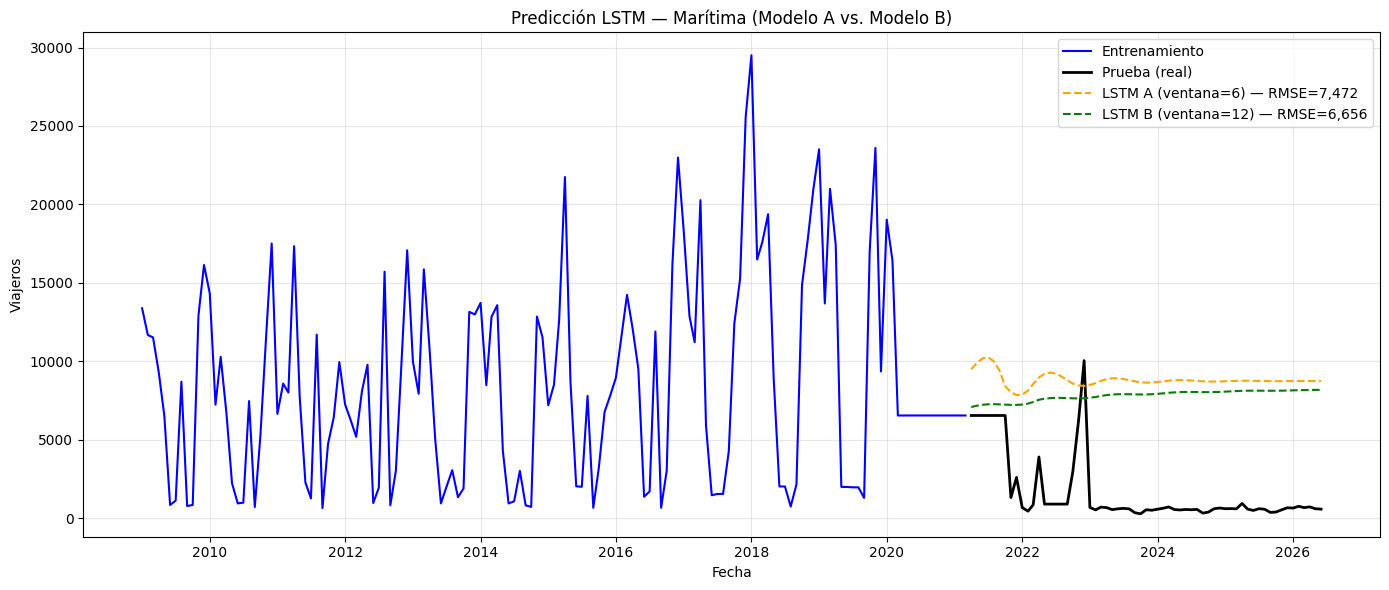

In [10]:
comparacion_maritima = pd.DataFrame({
    'Modelo': ['LSTM A (ventana=6)', 'LSTM B (ventana=12)', 'Holt-Winters (Lab1)', 'ARIMA/SARIMA (Lab1)'],
    'MAE':  [mae_A, mae_B, 1417.43, 2024.39],
    'RMSE': [rmse_A, rmse_B, 2450.56, 2613.24],
}).sort_values('RMSE')
print("\nComparación final Marítima (ordenado por RMSE, menor es mejor):")
print(comparacion_maritima.to_string(index=False))

plt.figure(figsize=(14, 6))
plt.plot(train_serie, label='Entrenamiento', color='blue')
plt.plot(test_serie, label='Prueba (real)', color='black', linewidth=2)
plt.plot(pred_A.index, pred_A, label=f'LSTM A (ventana=6) — RMSE={rmse_A:,.0f}', linestyle='--', color='orange')
plt.plot(pred_B.index, pred_B, label=f'LSTM B (ventana=12) — RMSE={rmse_B:,.0f}', linestyle='--', color='green')
plt.title('Predicción LSTM — Marítima (Modelo A vs. Modelo B)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()